# 01. 워크플로우 vs 에이전트: 패턴 선택 가이드

> 같은 LangGraph로도 **워크플로우(고정 경로)** 와 **에이전트(LLM이 동적 결정)** 를 모두 만들 수 있어요. 6가지 대표 워크플로우 패턴을 직접 구현하며 둘의 경계를 그어봐요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **워크플로우(Workflow)**와 **에이전트(Agent)**의 개념적 차이를 설명할 수 있어요
2. 6가지 워크플로우 패턴(Augmented LLM, Prompt Chaining, Parallelization, Routing, Orchestrator-Worker, Evaluator-Optimizer)을 코드로 구현할 수 있어요
3. Agent 패턴의 핵심 구조(tool loop, should_continue)를 이해하고 구현할 수 있어요
4. 주어진 요구사항에 맞는 적절한 패턴을 선택할 수 있어요

## 사전 지식

- Part 02에서 배운 `StateGraph`, `Node`, `Edge`, `START/END` 개념
- `add_messages` reducer와 `MessagesState` 활용법
- `InMemorySaver`를 사용한 체크포인터 기본 사용법

## 워크플로우와 에이전트란?

LLM 애플리케이션을 설계할 때 두 가지 큰 범주로 나뉘어요:

| 구분 | 워크플로우(Workflow) | 에이전트(Agent) |
|------|--------------------|-----------------|
| 제어 흐름 | **사전 정의된 고정 경로** | **LLM이 런타임에 동적으로 결정** |
| 예측 가능성 | 높음 | 낮음 |
| 유연성 | 낮음 | 높음 |
| 적합한 작업 | 명확한 단계, 반복 가능 | 복잡하고 오픈엔드한 작업 |
| 비용/지연 | 통제 가능 | 예측 어려움 |
| 비유 | 🏭 공장 조립 라인 (정해진 순서) | 🧑‍🍳 셰프 (재료 보고 즉흥 요리) |

> 🔑 **핵심 개념**: 워크플로우는 "어떤 순서로 무엇을 할지"가 코드에 미리 정해져 있어요. 에이전트는 LLM이 "다음에 무엇을 할지"를 스스로 결정해요. 둘 다 LangGraph로 구현하지만, 설계 철학이 달라요.

> 🎯 **강의 포인트**: 많은 실무 시스템이 워크플로우와 에이전트를 **혼합**해서 사용해요. 예를 들어, 전체 파이프라인은 워크플로우로 고정하되, 특정 단계에서는 LLM이 도구를 선택하도록 에이전트를 내장하는 방식이에요.

아래 다이어그램으로 전체 패턴 지형을 살펴볼게요:

```mermaid
flowchart TD
    ROOT["LLM 시스템 아키텍처"] --> WF["워크플로우 Workflow<br/>고정된 제어 흐름"]
    ROOT --> AG["에이전트 Agent<br/>LLM이 흐름 결정"]

    WF --> P1["Augmented LLM<br/>도구+검색+메모리"]
    WF --> P2["Prompt Chaining<br/>순차 체이닝"]
    WF --> P3["Parallelization<br/>병렬 처리"]
    WF --> P4["Routing<br/>입력 분기"]
    WF --> P5["Orchestrator-Worker<br/>동적 태스크 분배"]
    WF --> P6["Evaluator-Optimizer<br/>자기 개선 루프"]

    AG --> A1["Tool Loop<br/>도구 호출 반복"]

    classDef root fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef workflow fill:#cce5ff,stroke:#007bff,color:#004085
    classDef agent fill:#d4edda,stroke:#28a745,color:#155724
    classDef pattern fill:#fff3cd,stroke:#ffc107,color:#856404

    class ROOT root
    class WF workflow
    class AG agent
    class P1,P2,P3,P4,P5,P6,A1 pattern
```

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 읽어와요)
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (학습 중 그래프 실행 과정을 추적할 수 있어요)
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Part03-Patterns"

## 1. 패턴 1: Augmented LLM (증강 LLM)

가장 기본적인 패턴이에요. LLM에 **도구(Tools)**, **검색(Retrieval)**, **메모리(Memory)** 를 추가해서 능력을 확장해요.

```mermaid
flowchart LR
    IN["입력"] --> LLM["LLM"]
    LLM <--> T["도구 Tools"]
    LLM <--> R["검색 Retrieval"]
    LLM <--> M["메모리 Memory"]
    LLM --> OUT["출력"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class IN input
    class LLM process
    class OUT output
    class T,R,M storage
```

> 🔑 **핵심 개념**: Augmented LLM은 다른 모든 패턴의 **기반 빌딩 블록**이에요. 도구를 bind_tools로 연결하면, LLM은 필요할 때 해당 도구를 호출하도록 훈련되어 있어요.

> 💡 **실무 팁**: 도구를 너무 많이 추가하면 LLM이 어떤 도구를 선택할지 혼란스러워해요. 실무에서는 5~10개 이내로 제한하고, 도구 설명(docstring)을 명확하게 작성하는 것이 중요해요.

In [3]:
# LangChain V1 핵심 임포트
from langchain.chat_models import init_chat_model
from langchain.tools import tool

# 기본 모델 초기화: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델 사용 예시:
#   - Anthropic: "anthropic:claude-sonnet-4-5"
#   - Google Gemini: "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")

In [4]:
# ---------------------------------------------------
# Augmented LLM: 도구 정의 및 모델에 바인딩
# ---------------------------------------------------

@tool
def get_weather(city: str) -> str:
    """도시의 현재 날씨를 조회해요."""
    # 실습용 더미 데이터 (실제로는 날씨 API를 호출해요)
    weather_db = {
        "서울": "맑음, 22°C",
        "부산": "흐림, 18°C",
        "제주": "비, 15°C",
    }
    return weather_db.get(city, f"{city}: 날씨 정보를 찾을 수 없어요")

@tool
def calculate(expression: str) -> str:
    """수식을 계산해요. 예: '2 + 3 * 4'"""
    try:
        result = eval(expression)  # 교육용: 실제로는 안전한 eval 사용 필요
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

# 모델에 도구를 바인딩해요 (LLM이 이 도구들을 호출할 수 있게 됨)
tools = [get_weather, calculate]
augmented_model = model.bind_tools(tools)

# Augmented LLM 준비 완료!
print(f"바인딩된 도구: {[t.name for t in tools]}")

바인딩된 도구: ['get_weather', 'calculate']


In [5]:
# ---------------------------------------------------
# Augmented LLM 테스트: 도구 호출 응답 확인
# ---------------------------------------------------
from langchain.messages import HumanMessage

# 날씨를 물어보면 LLM이 get_weather 도구 호출을 생성해요
response = augmented_model.invoke([HumanMessage(content="서울 날씨 알려줘")])

print(f"응답 타입: {type(response).__name__}")
print(f"도구 호출 여부: {bool(response.tool_calls)}")
if response.tool_calls:
    for tc in response.tool_calls:
        print(f"  - 도구: {tc['name']}, 인자: {tc['args']}")

응답 타입: AIMessage
도구 호출 여부: True
  - 도구: get_weather, 인자: {'city': '서울'}


## 2. 패턴 2: Prompt Chaining (프롬프트 체이닝)

### 왜 필요한가요?

하나의 복잡한 프롬프트로 모든 것을 처리하려고 하면 LLM이 혼란스러워하고, 결과의 품질이 들쑥날쑥해요. 마치 **한 사람에게 동시통역 + 요약 + 교정을 동시에 시키는 것**과 같아요. 각 전문가에게 한 가지씩 맡기는 것이 훨씬 신뢰성이 높죠.

작업을 **여러 순차적 단계**로 분해하여, 각 LLM 호출의 출력이 다음 단계의 입력이 되는 패턴이에요.

```mermaid
flowchart LR
    IN["입력"] --> S1["LLM 1<br/>초안 작성"]
    S1 --> G1{"품질 게이트 1"}
    G1 -->|통과| S2["LLM 2<br/>번역"]
    G1 -->|실패| END1["종료"]
    S2 --> G2{"품질 게이트 2"}
    G2 -->|통과| S3["LLM 3<br/>최종 검토"]
    G2 -->|실패| END2["종료"]
    S3 --> OUT["출력"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef gate fill:#f8d7da,stroke:#dc3545,color:#721c24

    class IN input
    class S1,S2,S3 process
    class OUT output
    class G1,G2 gate
```

> 🎯 **강의 포인트**: Prompt Chaining은 "각 단계를 전문 LLM에게 맡긴다"는 분업 원칙이에요. 하나의 복잡한 프롬프트보다 여러 단순한 프롬프트가 더 신뢰성 높은 결과를 낸다는 게 실무에서 검증된 원칙이에요.

> ⚠️ **자주 하는 실수**: 중간 단계의 출력을 그대로 다음 단계에 전달하면 오류가 전파돼요. **품질 게이트(Gate)** 를 추가해서, 중간 결과가 기준을 충족하지 못하면 일찍 종료하거나 재처리하도록 설계해야 해요.

In [6]:
# LangGraph 핵심 구성 요소 임포트
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain.messages import SystemMessage, HumanMessage

In [7]:
# ---------------------------------------------------
# Prompt Chaining: 3단계 콘텐츠 생성 파이프라인
# 1단계: 초안 작성 → 2단계: 영어 번역 → 3단계: 요약
# ---------------------------------------------------

# 상태 정의: 각 단계의 출력을 담을 필드
class ChainState(TypedDict):
    topic: str           # 입력 주제
    draft: str           # 1단계: 초안
    translated: str      # 2단계: 번역본
    summary: str         # 3단계: 최종 요약
    should_continue: bool  # 품질 게이트 통과 여부

def write_draft(state: ChainState) -> ChainState:
    """1단계: 주어진 주제로 한국어 초안을 작성해요."""
    response = model.invoke([
        SystemMessage(content="당신은 전문 작가예요. 주어진 주제로 2~3문장의 간결한 글을 써주세요."),
        HumanMessage(content=f"주제: {state['topic']}")
    ])
    print(f"[1단계 초안]\n{response.content}\n")
    return {"draft": response.content}

def quality_gate(state: ChainState) -> ChainState:
    """품질 게이트: 초안이 충분히 길면 다음 단계로 진행해요."""
    # 간단한 품질 기준: 50자 이상이어야 해요
    passed = len(state["draft"]) >= 50
    if not passed:
        # [품질 게이트] 초안이 너무 짧아요. 파이프라인을 중단해요.
        pass
    return {"should_continue": passed}

def translate_to_english(state: ChainState) -> ChainState:
    """2단계: 한국어 초안을 영어로 번역해요."""
    response = model.invoke([
        SystemMessage(content="Translate the following Korean text to English accurately."),
        HumanMessage(content=state["draft"])
    ])
    print(f"[2단계 번역]\n{response.content}\n")
    return {"translated": response.content}

def summarize(state: ChainState) -> ChainState:
    """3단계: 번역본을 한 줄로 요약해요."""
    response = model.invoke([
        SystemMessage(content="Summarize the following text in one sentence."),
        HumanMessage(content=state["translated"])
    ])
    print(f"[3단계 요약]\n{response.content}")
    return {"summary": response.content}

def should_continue_fn(state: ChainState) -> str:
    """품질 게이트 결과에 따라 다음 노드를 결정하는 라우터예요."""
    if state.get("should_continue", False):
        return "continue"  # 번역 단계로
    return "stop"         # 종료

# 그래프 구성
chain_graph = StateGraph(ChainState)

# 노드 추가
chain_graph.add_node("write_draft", write_draft)
chain_graph.add_node("quality_gate", quality_gate)
chain_graph.add_node("translate", translate_to_english)
chain_graph.add_node("summarize", summarize)

# 엣지 연결 (고정 경로)
chain_graph.add_edge(START, "write_draft")
chain_graph.add_edge("write_draft", "quality_gate")
# 품질 게이트에서 조건부 분기
chain_graph.add_conditional_edges(
    "quality_gate",
    should_continue_fn,
    {"continue": "translate", "stop": END}
)
chain_graph.add_edge("translate", "summarize")
chain_graph.add_edge("summarize", END)

# 그래프 컴파일
chain_app = chain_graph.compile()
# Prompt Chaining 그래프 구성 완료!

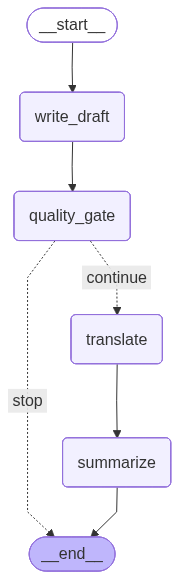

In [8]:
# 그래프 흐름: START → draft → translate → summarize → END
# draft: 초안 작성, translate: 영어 번역, summarize: 요약 생성
# ---------------------------------------------------
# 그래프 구조 시각화
# ---------------------------------------------------
from IPython.display import Image, display

display(Image(chain_app.get_graph().draw_mermaid_png()))

In [9]:
# ---------------------------------------------------
# Prompt Chaining 실행 테스트
# ---------------------------------------------------
result = chain_app.invoke({"topic": "인공지능이 미래 교육에 미치는 영향"})

# === 최종 결과 ===
print(f"최종 요약: {result.get('summary', '파이프라인이 중단되었어요')}")

[1단계 초안]
인공지능은 개인 맞춤형 학습 경험을 제공함으로써 미래 교육의 지형을 혁신할 것입니다. 학생의 학습 스타일과 속도에 맞춘 콘텐츠를 제안하고, 교사의 역할을 보조하여 더욱 효과적인 교육 환경을 조성할 수 있습니다. 이로 인해 교육 접근성이 향상되고, 보다 많은 사람들이 양질의 교육을 받을 수 있는 기회가 증가할 것입니다.

[2단계 번역]
Artificial intelligence will revolutionize the landscape of future education by providing personalized learning experiences. It can suggest content tailored to the learning styles and pace of students, assisting teachers and creating a more effective educational environment. As a result, accessibility to education will improve, increasing the opportunities for more people to receive quality education.

[3단계 요약]
Artificial intelligence is set to transform future education by offering personalized learning experiences, enhancing accessibility, and creating a more effective learning environment.
최종 요약: Artificial intelligence is set to transform future education by offering personalized learning experiences, enhancing accessibility, and creating a more effective learning environment.


## 3. 패턴 3: Parallelization (병렬화)

독립적인 작업을 **동시에** 실행하여 처리 속도를 높이는 패턴이에요. LangGraph에서는 분기(Fan-out)와 합류(Fan-in) 구조로 구현해요.

```mermaid
flowchart TD
    IN["입력"] --> SPLIT["Fan-out<br>분기"]
    SPLIT --> T1["LLM 1<br>감성 분석"]
    SPLIT --> T2["LLM 2<br>키워드 추출"]
    SPLIT --> T3["LLM 3<br>카테고리 분류"]
    T1 --> MERGE["Fan-in<br>합류"]
    T2 --> MERGE
    T3 --> MERGE
    MERGE --> OUT["통합 결과"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class IN input
    class SPLIT,T1,T2,T3 process
    class MERGE,OUT output
```

> 💡 **실무 팁**: 병렬화 패턴은 API 지연(latency)을 크게 줄여줘요. 3개의 LLM 호출이 순차적으로 5초씩 걸린다면 15초지만, 병렬 실행하면 약 5초로 단축돼요. 각 분석이 서로 독립적일 때 사용하세요.

> ⚠️ **자주 하는 실수**: 결과를 모아서 처리하는 "Fan-in" 노드에서 리스트가 예상대로 채워지지 않는 경우가 있어요. `Annotated[list, operator.add]`를 사용해서 각 브랜치의 결과가 **추가(add)** 되도록 reducer를 명시해야 해요.

In [10]:
# ---------------------------------------------------
# Parallelization: 텍스트 다중 분석 파이프라인
# 감성 분석, 키워드 추출, 카테고리 분류를 동시에 실행해요
# ---------------------------------------------------
import operator
from typing import Annotated

# 병렬 결과를 모으는 상태 정의
# Annotated[list, operator.add]: 각 브랜치의 결과를 리스트에 추가해요
class ParallelState(TypedDict):
    text: str                                    # 분석할 텍스트
    analysis_results: Annotated[list, operator.add]  # 병렬 결과 누적

def analyze_sentiment(state: ParallelState) -> dict:
    """감성(긍정/부정/중립)을 분석해요."""
    response = model.invoke([
        SystemMessage(content="이 텍스트의 감성을 분석해서 '긍정', '부정', '중립' 중 하나와 이유를 간단히 설명해주세요."),
        HumanMessage(content=state["text"])
    ])
    return {"analysis_results": [f"[감성분석] {response.content}"]}

def extract_keywords(state: ParallelState) -> dict:
    """주요 키워드 3개를 추출해요."""
    response = model.invoke([
        SystemMessage(content="이 텍스트에서 핵심 키워드를 3개만 추출해서 쉼표로 구분해주세요."),
        HumanMessage(content=state["text"])
    ])
    return {"analysis_results": [f"[키워드] {response.content}"]}

def classify_category(state: ParallelState) -> dict:
    """텍스트의 카테고리를 분류해요."""
    response = model.invoke([
        SystemMessage(content="이 텍스트를 '기술', '경제', '문화', '스포츠', '정치' 중 하나로 분류하고 이유를 설명해주세요."),
        HumanMessage(content=state["text"])
    ])
    return {"analysis_results": [f"[카테고리] {response.content}"]}

def merge_results(state: ParallelState) -> dict:
    """병렬 분석 결과를 하나로 합쳐요."""
    # === 병렬 분석 완료 ===
    for r in state["analysis_results"]:
        print(r)
    return {}  # 상태 변경 없이 출력만 해요

# 그래프 구성
parallel_graph = StateGraph(ParallelState)
parallel_graph.add_node("sentiment", analyze_sentiment)
parallel_graph.add_node("keywords", extract_keywords)
parallel_graph.add_node("category", classify_category)
parallel_graph.add_node("merge", merge_results)

# Fan-out: START에서 3개 노드로 동시에 분기
parallel_graph.add_edge(START, "sentiment")
parallel_graph.add_edge(START, "keywords")
parallel_graph.add_edge(START, "category")

# Fan-in: 3개 노드에서 merge 노드로 합류
parallel_graph.add_edge("sentiment", "merge")
parallel_graph.add_edge("keywords", "merge")
parallel_graph.add_edge("category", "merge")

parallel_graph.add_edge("merge", END)

parallel_app = parallel_graph.compile()
# Parallelization 그래프 구성 완료!

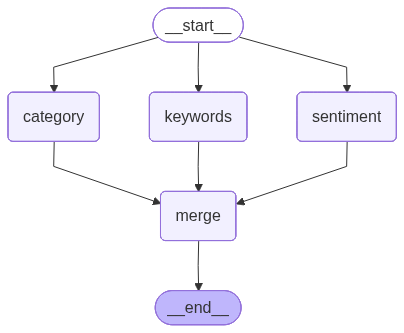

In [11]:
# 그래프 흐름: START → analyze_sentiment + extract_keywords + classify_category → aggregate → END
# 3개 분석 노드가 병렬 실행된 후 aggregate에서 결과를 합쳐요
# 그래프 구조 시각화
display(Image(parallel_app.get_graph().draw_mermaid_png()))

In [12]:
# ---------------------------------------------------
# 병렬 분석 실행
# ---------------------------------------------------
sample_text = "삼성전자가 새로운 AI 반도체를 개발했다고 발표했어요. 이 반도체는 기존 제품 대비 성능이 2배 향상되었으며, 전력 소비는 30% 감소했어요."

parallel_app.invoke({"text": sample_text, "analysis_results": []})

[카테고리] 이 텍스트는 '기술'로 분류할 수 있습니다. 이유는 삼성전자가 AI 반도체를 개발했다는 내용이 기술 혁신과 관련이 있으며, 성능 개선 및 전력 소비 감소와 같은 기술적 성과가 강조되고 있기 때문입니다. AI 반도체는 첨단 기술 분야의 중요한 요소로, 이러한 개발은 기술 발전에 큰 영향을 미칠 수 있습니다.
[키워드] 삼성전자, AI 반도체, 성능 향상
[감성분석] 감성: 긍정

이유: 삼성전자가 새로운 AI 반도체를 개발하고 성능이 향상되었으며 전력 소비가 감소했다고 발표한 것은 업계에 긍정적인 발전을 의미합니다. 이는 기술적 진보와 효율성을 나타내며, 소비자와 기업 모두에게 유익한 소식으로 해석될 수 있습니다.


{'text': '삼성전자가 새로운 AI 반도체를 개발했다고 발표했어요. 이 반도체는 기존 제품 대비 성능이 2배 향상되었으며, 전력 소비는 30% 감소했어요.',
 'analysis_results': ["[카테고리] 이 텍스트는 '기술'로 분류할 수 있습니다. 이유는 삼성전자가 AI 반도체를 개발했다는 내용이 기술 혁신과 관련이 있으며, 성능 개선 및 전력 소비 감소와 같은 기술적 성과가 강조되고 있기 때문입니다. AI 반도체는 첨단 기술 분야의 중요한 요소로, 이러한 개발은 기술 발전에 큰 영향을 미칠 수 있습니다.",
  '[키워드] 삼성전자, AI 반도체, 성능 향상',
  '[감성분석] 감성: 긍정\n\n이유: 삼성전자가 새로운 AI 반도체를 개발하고 성능이 향상되었으며 전력 소비가 감소했다고 발표한 것은 업계에 긍정적인 발전을 의미합니다. 이는 기술적 진보와 효율성을 나타내며, 소비자와 기업 모두에게 유익한 소식으로 해석될 수 있습니다.']}

## 4. 패턴 4: Routing (라우팅)

입력을 분류하여 **적절한 전문 처리 경로**로 보내는 패턴이에요. 각 경로는 해당 유형에 최적화된 LLM 또는 로직을 사용해요.

```mermaid
flowchart TD
    IN["입력"] --> ROUTER["분류기 LLM<br>Router"]
    ROUTER -->|"기술 문의"| T1["기술 전문 LLM"]
    ROUTER -->|"결제 문의"| T2["결제 전문 LLM"]
    ROUTER -->|"일반 문의"| T3["일반 응답 LLM"]
    T1 --> OUT["최종 응답"]
    T2 --> OUT
    T3 --> OUT

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef router fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class IN input
    class ROUTER router
    class T1,T2,T3 process
    class OUT output
```

> 🔑 **핵심 개념**: 라우팅에서 분류기(Router)는 규칙 기반(if/else)이 될 수도 있고, LLM 기반이 될 수도 있어요. LLM 기반 라우팅은 유연하지만 비용이 더 들어요. 분류 카테고리가 명확하고 패턴이 단순하면 규칙 기반을 먼저 고려해 보세요.

> 🎯 **강의 포인트**: 실무 고객 지원 챗봇의 핵심 패턴이에요. "어떤 부서로 연결할까?"를 LLM이 결정하고, 해당 부서 전문 모델이 실제 응답을 생성해요.

In [13]:
# ---------------------------------------------------
# Routing: 고객 문의 유형별 분기 처리
# ---------------------------------------------------
from typing import Literal

# 상태 정의
class RoutingState(TypedDict):
    query: str          # 사용자 문의
    category: str       # 분류 결과
    response: str       # 최종 응답

def classify_query(state: RoutingState) -> RoutingState:
    """사용자 문의를 카테고리로 분류해요."""
    response = model.invoke([
        SystemMessage(content="""사용자의 문의를 다음 카테고리 중 하나로 분류하세요.
반드시 이 중 하나만 응답하세요: technical, billing, general"""),
        HumanMessage(content=state["query"])
    ])
    # 응답에서 카테고리 추출 (소문자 정규화)
    raw = response.content.strip().lower()
    if "technical" in raw:
        category = "technical"
    elif "billing" in raw:
        category = "billing"
    else:
        category = "general"
    print(f"[라우터] 문의 분류 결과: {category}")
    return {"category": category}

def route_fn(state: RoutingState) -> Literal["technical", "billing", "general"]:
    """분류 결과에 따라 다음 노드를 결정하는 라우터예요."""
    return state["category"]

def handle_technical(state: RoutingState) -> RoutingState:
    """기술 문의를 전문적으로 처리해요."""
    response = model.invoke([
        SystemMessage(content="당신은 기술 지원 전문가예요. 기술적인 문제를 단계별로 친절하게 안내해주세요."),
        HumanMessage(content=state["query"])
    ])
    return {"response": f"[기술지원팀] {response.content}"}

def handle_billing(state: RoutingState) -> RoutingState:
    """결제 문의를 처리해요."""
    response = model.invoke([
        SystemMessage(content="당신은 결제 담당 직원이에요. 결제 관련 문의를 정확하고 신속하게 처리해주세요."),
        HumanMessage(content=state["query"])
    ])
    return {"response": f"[결제팀] {response.content}"}

def handle_general(state: RoutingState) -> RoutingState:
    """일반 문의를 처리해요."""
    response = model.invoke([
        SystemMessage(content="당신은 친절한 고객 상담원이에요. 일반적인 문의에 도움을 드리세요."),
        HumanMessage(content=state["query"])
    ])
    return {"response": f"[고객지원팀] {response.content}"}

# 그래프 구성
routing_graph = StateGraph(RoutingState)
routing_graph.add_node("classify", classify_query)
routing_graph.add_node("technical", handle_technical)
routing_graph.add_node("billing", handle_billing)
routing_graph.add_node("general", handle_general)

routing_graph.add_edge(START, "classify")
# 조건부 엣지: category에 따라 해당 처리 노드로 분기
routing_graph.add_conditional_edges(
    "classify",
    route_fn,
    {"technical": "technical", "billing": "billing", "general": "general"}
)
routing_graph.add_edge("technical", END)
routing_graph.add_edge("billing", END)
routing_graph.add_edge("general", END)

routing_app = routing_graph.compile()
# Routing 그래프 구성 완료!

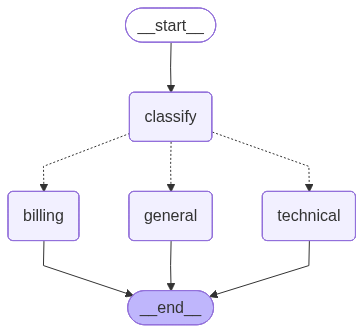

In [14]:
# 그래프 흐름: START → classify_inquiry → tech_support/billing_support/general_support → END
# classify_inquiry 노드: 문의 유형을 분류해요
# 조건부 엣지: 분류 결과에 따라 해당 지원 노드로 분기해요
# 그래프 구조 시각화
display(Image(routing_app.get_graph().draw_mermaid_png()))

In [15]:
# ---------------------------------------------------
# 라우팅 테스트: 다양한 문의 유형 테스트
# ---------------------------------------------------

queries = [
    "앱이 자꾸 오류가 나요. 어떻게 해결하나요?",   # → 기술 문의
    "이번 달 요금이 왜 이렇게 많이 나왔나요?",     # → 결제 문의
    "영업 시간이 언제인가요?",                     # → 일반 문의
]

for query in queries:
    print(f"\n질문: {query}")
    result = routing_app.invoke({"query": query})
    print(f"응답: {result['response'][:100]}...")
    # ------------------------------------------------------------


질문: 앱이 자꾸 오류가 나요. 어떻게 해결하나요?
[라우터] 문의 분류 결과: technical
응답: [기술지원팀] 앱 오류 문제를 해결하기 위해 다음 단계를 따라 진행해 보세요.

### 1단계: 기본 문제 해결
1. **앱 재시작**:
   - 앱을 완전히 닫고(멀티태스킹 화면...

질문: 이번 달 요금이 왜 이렇게 많이 나왔나요?
[라우터] 문의 분류 결과: billing
응답: [결제팀] 이번 달 요금이 많이 나온 이유는 여러 가지가 있을 수 있습니다. 사용량이 증가했거나, 요금제가 변경되었거나, 추가 서비스나 상품이 결제되었을 수 있습니다. 

정확한 ...

질문: 영업 시간이 언제인가요?
[라우터] 문의 분류 결과: general
응답: [고객지원팀] 저희 영업 시간은 일반적으로 평일 오전 9시부터 오후 6시까지입니다. 토요일과 일요일은 휴무입니다. 특정 매장이나 서비스에 따라 다를 수 있으니, 자세한 사항은 해당...


## 5. 패턴 5: Orchestrator-Worker (오케스트레이터-워커)

### 왜 필요한가요?

앞서 배운 Parallelization은 **분석 항목이 미리 정해져 있을 때** 유용해요. 하지만 "이 주제를 깊이 분석해줘"처럼 **몇 개의 서브태스크가 필요한지 미리 알 수 없는 경우**가 있어요. 이때 LLM이 직접 태스크를 분해하고 배분하는 오케스트레이터-워커 패턴이 필요해요. 마치 **프로젝트 매니저**가 업무를 파악하고 팀원에게 배분하는 것과 같아요.

중앙 오케스트레이터 LLM이 태스크를 동적으로 분해하고, 워커들에게 **병렬로 배분**하는 패턴이에요. LangGraph의 `Send` API를 사용해서 동적으로 워커를 생성해요.

```mermaid
flowchart TD
    IN["입력"] --> ORCH["오케스트레이터<br/>Orchestrator LLM"]
    ORCH -->|"Send API"| W1["워커 1<br/>Worker"]
    ORCH -->|"필요 시 Send"| W2["워커 2<br/>Worker<br/>(선택)"]
    ORCH -->|"필요 시 Send"| W3["워커 3<br/>Worker<br/>(선택)"]
    W1 --> SYNTH["합성<br/>Synthesizer"]
    W2 --> SYNTH
    W3 --> SYNTH
    SYNTH --> OUT["최종 결과"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef orch fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef worker fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class IN input
    class ORCH,SYNTH orch
    class W1,W2,W3 worker
    class OUT output
```

### Parallelization vs Orchestrator-Worker

| 비교 항목 | Parallelization | Orchestrator-Worker |
|-----------|----------------|---------------------|
| 태스크 수 | **코드에 미리 정의** | **LLM이 런타임에 결정** |
| 핵심 API | `add_edge(START, "node")` 다중 등록 | `Send` API로 동적 생성 |
| 유연성 | 낮음 (고정 분기) | 높음 (동적 분기) |
| 적합한 경우 | 고정된 분석 항목 | 입력에 따라 태스크 수가 달라질 때 |

> 🔑 **핵심 개념**: `Send` API는 LangGraph의 강력한 기능이에요. 일반 엣지는 다음 노드를 미리 고정하지만, `Send`는 **런타임에 동적으로 여러 워커 실행을 생성**해요. 오케스트레이터가 N개의 서브태스크를 결정하면 같은 `worker` 노드가 N번 병렬 실행돼요.

> 👀 **그래프를 볼 때 주의**: 컴파일된 그래프에는 `worker` 노드가 하나만 보일 수 있어요. 이 노드는 "워커 템플릿"이고, 아래 예제에서는 오케스트레이터가 주제 난이도에 따라 1~3개의 분석 항목을 고르면 `dispatch_workers`가 그 수만큼 `Send(...)`를 반환해요. 즉 실행 시점에 `worker-1`만 생길 수도 있고, 최대 `worker-3`까지 생길 수도 있어요.

> 🎯 **강의 포인트**: 코드 리뷰, 문서 분석, 대용량 리포트 생성에 자주 사용되는 패턴이에요. 각 섹션을 독립적으로 처리하고 나중에 합치는 방식이 핵심이에요.

In [16]:
# ---------------------------------------------------
# Orchestrator-Worker: Send API 기반 동적 분석
# 오케스트레이터가 분석 항목 수를 판단하고 최대 3개 워커에 배분해요
# ---------------------------------------------------
from langgraph.types import Send

MAX_WORKERS = 3  # 비용/지연을 통제하기 위해 워커는 최대 3개까지만 허용해요

# 메인 상태: 전체 파이프라인 상태
class OrchestratorState(TypedDict):
    topic: str                                   # 분석 주제
    sections: list[str]                          # 오케스트레이터가 생성한 분석 항목
    results: Annotated[list[str], operator.add]  # 워커들의 결과 (자동 누적)
    final_report: str                            # 최종 합성 결과

# 워커 상태: 각 워커는 독립적인 입력을 받아요
class WorkerState(TypedDict):
    topic: str      # 전체 주제 (컨텍스트용)
    section: str    # 담당 분석 항목
    worker_id: int  # 실행 로그에서 워커를 구분하기 위한 번호

def _clean_section(line: str) -> str:
    """LLM이 번호/기호를 붙여도 섹션 제목만 남겨요."""
    return line.strip().lstrip("-*•0123456789. )").strip()

def orchestrate(state: OrchestratorState) -> OrchestratorState:
    """오케스트레이터: 주제 복잡도에 따라 분석 항목을 1~3개로 결정해요."""
    response = model.invoke([
        SystemMessage(content=f"""당신은 분석 작업을 나누는 오케스트레이터입니다.
주어진 주제의 복잡도를 판단해서 서로 겹치지 않는 심층 분석 하위 항목을 1개 이상 {MAX_WORKERS}개 이하로 제안하세요.
- 단순한 주제: 1개
- 보통 복잡도: 2개
- 여러 관점이 필요한 주제: 3개
각 항목을 줄바꿈으로 구분해서 답변하세요. 번호나 기호 없이 항목 텍스트만 적어주세요."""),
        HumanMessage(content=f"분석 주제: {state['topic']}")
    ])

    sections = [
        _clean_section(line)
        for line in response.content.split("\n")
        if _clean_section(line)
    ]
    sections = sections[:MAX_WORKERS]

    # 교육용 안전장치: 모델이 빈 응답을 반환하면 최소 1개 워커는 실행되게 해요.
    if not sections:
        sections = ["핵심 맥락"]

    print(f"[오케스트레이터] {len(sections)}개 분석 항목 생성: {sections}")
    return {"sections": sections}

def dispatch_workers(state: OrchestratorState) -> list[Send]:
    """오케스트레이터가 정한 섹션 수만큼 워커 실행을 동적으로 생성해요."""
    sends = []
    for worker_id, section in enumerate(state["sections"], start=1):
        print(f"[디스패치] worker-{worker_id} 생성 → {section}")
        sends.append(
            Send(
                "worker",
                {
                    "topic": state["topic"],
                    "section": section,
                    "worker_id": worker_id,
                },
            )
        )
    return sends

def worker_fn(state: WorkerState) -> dict:
    """워커: 담당 섹션을 분석해서 결과를 반환해요."""
    print(f"[워커-{state['worker_id']}] '{state['section']}' 분석 시작")
    response = model.invoke([
        SystemMessage(content="주어진 항목에 대해 2~3문장으로 핵심 내용을 작성하세요."),
        HumanMessage(content=f"주제: {state['topic']}\n분석 항목: {state['section']}")
    ])
    print(f"[워커-{state['worker_id']}] 분석 완료")

    # 결과를 OrchestratorState.results에 추가 (operator.add로 자동 합산)
    return {"results": [f"### 워커 {state['worker_id']}: {state['section']}\n{response.content}"]}

def synthesize(state: OrchestratorState) -> OrchestratorState:
    """합성기: 모든 워커의 결과를 하나의 리포트로 통합해요."""
    all_results = "\n\n".join(state["results"])
    response = model.invoke([
        SystemMessage(content="다음 분석 결과들을 통합해서 300자 이내의 요약 리포트를 작성하세요."),
        HumanMessage(content=all_results)
    ])
    print(f"\n[합성] {len(state['results'])}개 워커 결과 통합 완료")
    return {"final_report": response.content}

# 그래프 구성
orchestrator_graph = StateGraph(OrchestratorState)
orchestrator_graph.add_node("orchestrate", orchestrate)
orchestrator_graph.add_node("worker", worker_fn)  # 워커 템플릿 노드: Send가 실행 시점에 1~3번 호출해요
orchestrator_graph.add_node("synthesize", synthesize)

orchestrator_graph.add_edge(START, "orchestrate")
# 조건부 엣지: dispatch_workers가 Send 리스트를 반환해서 필요한 수만큼 워커 실행을 동적으로 생성
orchestrator_graph.add_conditional_edges("orchestrate", dispatch_workers, ["worker"])
orchestrator_graph.add_edge("worker", "synthesize")
orchestrator_graph.add_edge("synthesize", END)

orchestrator_app = orchestrator_graph.compile()
# Orchestrator-Worker 그래프 구성 완료!


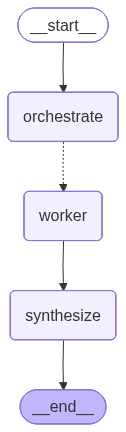

In [17]:
# 그래프 흐름: START → orchestrate → worker(동적 1~3회 실행) → synthesize → END
# 주의: 컴파일된 그래프에는 worker 노드가 하나만 보여요.
# 이 노드는 템플릿이고, 실행할 때 Send가 worker-1부터 최대 worker-3까지 동적으로 만들어요.
# 그래프 구조 시각화
display(Image(orchestrator_app.get_graph().draw_mermaid_png()))


In [18]:
# ---------------------------------------------------
# Orchestrator-Worker 실행
# 실행 로그에서 오케스트레이터가 몇 개의 worker를 만들었는지 확인해요
# ---------------------------------------------------
result = orchestrator_app.invoke({
    "topic": "도지코인과 테슬라"
})

# ========================================
# 최종 리포트
# ========================================
print(result["final_report"])


[오케스트레이터] 2개 분석 항목 생성: ['도지코인의 경제적 영향과 시장 반응', '테슬라의 도지코인 수용이 브랜드 이미지에 미치는 영향']
[디스패치] worker-1 생성 → 도지코인의 경제적 영향과 시장 반응
[디스패치] worker-2 생성 → 테슬라의 도지코인 수용이 브랜드 이미지에 미치는 영향
[워커-1] '도지코인의 경제적 영향과 시장 반응' 분석 시작
[워커-2] '테슬라의 도지코인 수용이 브랜드 이미지에 미치는 영향' 분석 시작
[워커-2] 분석 완료
[워커-1] 분석 완료

[합성] 2개 워커 결과 통합 완료
도지코인은 일론 머스크의 지지로 인해 큰 시장 반응을 얻고 있으며, 그의 긍정적 발언 시 가격 상승이 두드러진다. 이는 암호화폐의 대중화와 기술적 혁신을 촉진하며 투자자에게 새로운 기회를 창출한다. 또한, 테슬라가 도지코인을 수용함에 따라 브랜드 이미지는 현대적이고 혁신적인 방향으로 강화되며, 젊은 투자자와 암호화폐 커뮤니티와의 관계도 강화된다. 이는 테슬라의 기술적 선도성을 강조하고 소비자에게 독특한 경험을 제공한다.


## 6. 패턴 6: Evaluator-Optimizer (평가자-최적화자)

LLM이 생성한 결과를 **평가자 LLM**이 검토하고, 기준을 충족하지 못하면 **반복 개선**하는 패턴이에요.

```mermaid
flowchart TD
    IN["입력"] --> GEN["생성기 LLM<br>Generator"]
    GEN --> EVAL["평가자 LLM<br>Evaluator"]
    EVAL -->|"통과 PASS"| OUT["최종 출력"]
    EVAL -->|"개선 필요<br>FAIL + 피드백"| GEN

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef gen fill:#cce5ff,stroke:#007bff,color:#004085
    classDef eval fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class IN input
    class GEN gen
    class EVAL eval
    class OUT output
```

> 💡 **실무 팁**: 무한 루프를 방지하기 위해 반드시 **최대 반복 횟수(max_iterations)** 를 설정해야 해요. 실무에서는 보통 3~5회로 제한해요. 루프를 너무 많이 돌면 비용이 급격히 증가해요.

> ⚠️ **자주 하는 실수**: 평가 기준을 너무 엄격하게 설정하면 루프가 빠져나오지 못해요. 평가자의 프롬프트에 "완벽하지 않아도 충분히 좋으면 PASS"라는 기준을 명시해야 해요.

In [19]:
# ---------------------------------------------------
# Evaluator-Optimizer: 생성 + 자기 개선 루프
# 평가자가 생성된 결과를 검토하고 개선 피드백을 제공해요
# ---------------------------------------------------

class EvalState(TypedDict):
    task: str           # 수행할 작업
    result: str         # 현재 생성된 결과
    feedback: str       # 평가자의 피드백
    iterations: int     # 현재 반복 횟수
    max_iterations: int # 최대 반복 횟수 (무한 루프 방지)
    approved: bool      # 평가 통과 여부

def generate(state: EvalState) -> EvalState:
    """생성기: 작업을 수행하거나 피드백을 반영해서 개선해요."""
    if state["feedback"]:
        # 이전 피드백이 있으면 개선 요청
        prompt = f"다음 결과를 피드백에 따라 개선해주세요.\n\n원래 결과:\n{state['result']}\n\n피드백:\n{state['feedback']}"
    else:
        # 처음 생성
        prompt = f"다음 작업을 수행해주세요: {state['task']}"

    response = model.invoke([HumanMessage(content=prompt)])
    new_iteration = state["iterations"] + 1
    print(f"\n[생성기 - {new_iteration}회차]\n{response.content[:200]}...")
    return {"result": response.content, "iterations": new_iteration}

def evaluate(state: EvalState) -> EvalState:
    """평가자: 결과를 검토하고 PASS 또는 개선 피드백을 반환해요."""
    response = model.invoke([
        SystemMessage(content="""당신은 엄격한 품질 검토자예요.
제출된 결과를 검토하고 다음 형식으로 응답하세요:
- 기준을 충족하면: 'PASS'
- 개선이 필요하면: 'FAIL: [구체적인 개선 방향]'

품질 기준(모두 충족해야 PASS):
1. 한국어로 자연스럽게 작성
2. 150자 이상, 400자 이하
3. 핵심 차이점을 구체적인 예시와 함께 설명"""),
        HumanMessage(content=f"원래 작업: {state['task']}\n\n제출 결과:\n{state['result']}")
    ])
    evaluation = response.content.strip()
    approved = evaluation.startswith("PASS")
    feedback = "" if approved else evaluation.replace("FAIL:", "").strip()

    status = "통과" if approved else f"개선 필요: {feedback[:50]}..."
    print(f"[평가자] {status}")
    return {"approved": approved, "feedback": feedback}

def should_continue_eval(state: EvalState) -> str:
    """평가 결과와 반복 횟수에 따라 계속할지 종료할지 결정해요."""
    if state["approved"]:
        print(f"\n총 {state['iterations']}회 만에 승인 완료!")
        return "approved"
    if state["iterations"] >= state["max_iterations"]:
        print(f"\n최대 반복 횟수({state['max_iterations']}회) 도달, 종료해요.")
        return "max_reached"
    return "retry"  # 다시 생성

# 그래프 구성
eval_graph = StateGraph(EvalState)
eval_graph.add_node("generate", generate)
eval_graph.add_node("evaluate", evaluate)

eval_graph.add_edge(START, "generate")
eval_graph.add_edge("generate", "evaluate")
# 평가 결과에 따라 분기
eval_graph.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"approved": END, "max_reached": END, "retry": "generate"}
)

eval_app = eval_graph.compile()
# Evaluator-Optimizer 그래프 구성 완료!


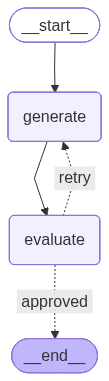

In [20]:
# 그래프 흐름: START → generate → evaluate → generate(루프) 또는 END
# generate 노드: 코드를 생성해요
# evaluate 노드: 코드를 평가하고 개선 여부를 결정해요
# 조건부 엣지: 품질 미달이면 generate로 루프, 합격이면 END로 이동해요
# 그래프 구조 시각화
display(Image(eval_app.get_graph().draw_mermaid_png()))

In [ ]:
# ---------------------------------------------------
# Evaluator-Optimizer 실행
# ---------------------------------------------------
result = eval_app.invoke({
    "task": "LangChain과 LangGraph의 차이점을 간단히 설명해줘",
    "result": "",
    "feedback": "",
    "iterations": 0,
    "max_iterations": 3,   # 최대 3회 반복
    "approved": False
})

# ========================================
# 최종 승인된 결과
# ========================================
print(result["result"])


[생성기 - 1회차]
LangChain과 LangGraph는 모두 자연어 처리(NLP) 및 언어 모델을 활용하는 플랫폼이지만, 그 목적과 기능에서 차이점이 있습니다.

### LangChain
- **목적**: LangChain은 언어 모델을 기반으로 한 애플리케이션 개발을 용이하게 만들어주는 프레임워크입니다. 데이터 소스와 모델 간의 상호작용, 체인 조합 등을 효율적으로 처리...
[평가자] 통과

총 1회 만에 승인 완료!
LangChain과 LangGraph는 모두 자연어 처리(NLP) 및 언어 모델을 활용하는 플랫폼이지만, 그 목적과 기능에서 차이점이 있습니다.

### LangChain
- **목적**: LangChain은 언어 모델을 기반으로 한 애플리케이션 개발을 용이하게 만들어주는 프레임워크입니다. 데이터 소스와 모델 간의 상호작용, 체인 조합 등을 효율적으로 처리할 수 있도록 설계되었습니다.
- **기능**: LangChain은 여러 가지 도구 및 기능을 제공합니다. 예를 들어, 텍스트 처리, 질문 응답, 대화형 애플리케이션 구축 등에 사용할 수 있습니다. 이를 통해 개발자는 간단하게 복잡한 작업을 조합하여 비즈니스 로직을 구현할 수 있습니다.
- **구조**: 프레임워크는 다양한 모듈이 구성되어 있으며, 이를 통해 언어 모델과 다양한 데이터 소스를 유기적으로 연결하여 사용할 수 있습니다.

### LangGraph
- **목적**: LangGraph는 언어 모델의 사용자 상호작용을 시각화하고 분석하는 플랫폼입니다. 주로 언어 모델의 결과를 그래프 형태로 시각적으로 표현하여 사용자가 쉽게 이해하고 활용할 수 있도록 돕습니다.
- **기능**: LangGraph는 언어 모델의 다양한 출력을 다이나믹하게 연결하고 표현할 수 있는 기능을 제공합니다. 사용자는 이를 통해 데이터 간의 관계를 시각적으로 인식하고, 보다 깊이 있는 분석을 수행할 수 있습니다.
- **구조**: 그래프 기반의 구조를 가지고 있어, 데이터 및 관계를 시각적으로 표현하는 데 

## 7. Agent 패턴: 자율 에이전트

### 워크플로우와 뭐가 다른가요?

지금까지 본 6가지 워크플로우 패턴은 모두 **"다음에 뭘 할지"를 코드가 결정**했어요. 에이전트는 근본적으로 달라요. **LLM 스스로** 도구를 호출할지, 언제 멈출지를 결정해요. 마치 직원에게 "이 일을 알아서 처리해줘"라고 맡기는 것과 같아요. `should_continue` 함수가 에이전트 루프의 핵심이에요.

```mermaid
flowchart TD
    IN["입력"] --> LLM_NODE["LLM 노드<br/>call_llm"]
    LLM_NODE --> CHECK{"should_continue?<br/>tool_calls 확인"}
    CHECK -->|"도구 호출 있음"| TOOLS["도구 실행 노드<br/>tool_node"]
    CHECK -->|"도구 호출 없음<br/>(LLM이 충분하다고 판단)"| OUT["최종 응답"]
    TOOLS --> LLM_NODE

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef llm fill:#cce5ff,stroke:#007bff,color:#004085
    classDef tools fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef check fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#f8d7da,stroke:#dc3545,color:#721c24

    class IN input
    class LLM_NODE llm
    class TOOLS tools
    class CHECK check
    class OUT output
```

> 🔑 **핵심 개념**: 에이전트 루프는 **"LLM -> 도구 -> LLM -> 도구 -> ... -> 종료"** 패턴이에요. LLM이 "도구를 더 호출하지 않겠다"고 결정하면 루프가 멈춰요. 이때 `should_continue`는 `tool_calls`가 있는지 확인해요.

> 🎯 **강의 포인트**: `MessagesState`는 LangGraph에서 제공하는 편의 상태 타입이에요. `messages` 필드에 `add_messages` reducer가 자동으로 적용돼서 메시지를 추가/업데이트할 수 있어요. 직접 `TypedDict`에 `Annotated[list, add_messages]`를 정의하는 것과 동일해요.

> ⚠️ **자주 하는 실수**: 에이전트는 LLM이 "충분히 답변했다"고 판단할 때 종료해요. 하지만 복잡한 질문에서는 도구를 계속 호출하며 비용이 예측 불가능하게 늘어날 수 있어요. 프로덕션에서는 **최대 반복 횟수**(`recursion_limit`)를 반드시 설정하세요.

In [22]:
# ---------------------------------------------------
# Agent 패턴: tool loop + should_continue
# MessagesState를 사용한 도구 호출 에이전트
# ---------------------------------------------------
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langchain.messages import SystemMessage

# 에이전트가 사용할 도구 정의
@tool
def search_web(query: str) -> str:
    """웹에서 정보를 검색해요."""
    # 교육용 더미 응답
    return f"'{query}' 검색 결과: [LangGraph V1은 2025년 말 출시되었으며, StateGraph와 Functional API 두 가지 방식을 지원해요.]"

@tool
def get_current_date() -> str:
    """현재 날짜와 시간을 반환해요."""
    from datetime import datetime
    return datetime.now().strftime("%Y년 %m월 %d일 %H:%M")

# 에이전트 도구 목록
agent_tools = [search_web, get_current_date, get_weather, calculate]

# 도구 바인딩된 모델 생성
agent_model = model.bind_tools(agent_tools)

# LangGraph 내장 ToolNode: tool_calls를 자동으로 실행해줘요
tool_node = ToolNode(agent_tools)

def call_model(state: MessagesState) -> MessagesState:
    """LLM 노드: 시스템 메시지와 함께 모델을 호출해요."""
    system = SystemMessage(content="당신은 유용한 AI 어시스턴트예요. 필요하면 도구를 사용하세요.")
    response = agent_model.invoke([system] + state["messages"])
    return {"messages": [response]}

def should_continue(state: MessagesState) -> str:
    """에이전트 루프 제어: 도구 호출 여부에 따라 경로를 결정해요."""
    last_message = state["messages"][-1]
    # 마지막 메시지에 tool_calls가 있으면 도구 노드로
    if last_message.tool_calls:
        return "use_tools"
    # 없으면 종료
    return "done"

# 에이전트 그래프 구성
agent_graph = StateGraph(MessagesState)
agent_graph.add_node("llm", call_model)
agent_graph.add_node("tools", tool_node)

agent_graph.add_edge(START, "llm")
agent_graph.add_conditional_edges(
    "llm",
    should_continue,
    {"use_tools": "tools", "done": END}
)
agent_graph.add_edge("tools", "llm")  # 도구 실행 후 다시 LLM으로

agent_app = agent_graph.compile()
# Agent 그래프 구성 완료!

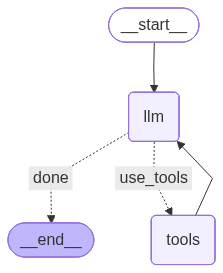

In [23]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM이 도구 호출 여부를 판단해요
# tools 노드: 도구를 실행하고 결과를 agent로 반환해요
# 조건부 엣지: tool_call이 있으면 tools, 없으면 END로 분기해요
# 그래프 구조 시각화
display(Image(agent_app.get_graph().draw_mermaid_png()))

In [24]:
# ---------------------------------------------------
# 에이전트 실행: 도구 호출 과정 추적
# ---------------------------------------------------
from langchain.messages import HumanMessage

# 도구를 여러 개 사용해야 하는 복합 질문
user_query = "지금 서울 날씨는 어때요? 그리고 오늘 날짜도 알려주세요."

print(f"사용자: {user_query}\n")

# 스트리밍으로 실행 과정을 단계별로 출력
for chunk in agent_app.stream(
    {"messages": [HumanMessage(content=user_query)]},
    stream_mode="updates"
):
    for node_name, node_output in chunk.items():
        print(f"--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()
        print()

사용자: 지금 서울 날씨는 어때요? 그리고 오늘 날짜도 알려주세요.

--- llm ---
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_rg6tdG2kkOiytPtOxH4HbTUM)
 Call ID: call_rg6tdG2kkOiytPtOxH4HbTUM
  Args:
    city: 서울
  get_current_date (call_6fQENeSnDj0GDPlfmtqFsEqj)
 Call ID: call_6fQENeSnDj0GDPlfmtqFsEqj
  Args:

--- tools ---
================================= Tool Message =================================
Name: get_weather

맑음, 22°C
================================= Tool Message =================================
Name: get_current_date

2026년 05월 19일 10:05

--- llm ---
================================== Ai Message ==================================

지금 서울의 날씨는 맑고 기온은 22°C입니다. 오늘 날짜는 2026년 5월 19일입니다.



## 8. 패턴 선택 가이드

실제 문제를 만났을 때 어떤 패턴을 선택해야 할지 알아볼게요.

> 🎯 **강의 포인트**: 패턴 선택은 **예측 가능성 vs 유연성** 트레이드오프예요. 프로덕션 환경에서는 가능하면 워크플로우 패턴을 먼저 시도하고, 워크플로우로 해결이 안 될 때 에이전트를 도입하는 것을 권장해요.

| 패턴 | 언제 사용? | 핵심 특징 | 주의사항 |
|------|-----------|-----------|----------|
| **Augmented LLM** | 도구나 검색이 필요한 단순 작업 | 도구 바인딩, 기본 블록 | 도구 수 5~10개 이내 |
| **Prompt Chaining** | 순차적 단계가 명확한 작업 | 품질 게이트, 단계별 전문화 | 오류 전파 방지 필요 |
| **Parallelization** | 독립적 서브태스크가 있는 작업 | Fan-out/Fan-in, operator.add | 결과 합산 reducer 필요 |
| **Routing** | 입력 유형에 따라 다른 처리가 필요 | 분류기 LLM, 전문 처리 경로 | 분류 실패 케이스 처리 |
| **Orchestrator-Worker** | 태스크 수를 미리 알 수 없는 경우 | Send API, 동적 워커 생성 | 워커 수 급증 시 비용 |
| **Evaluator-Optimizer** | 품질 기준이 있는 반복 개선 작업 | 피드백 루프, 자기 개선 | 최대 반복 횟수 설정 필수 |
| **Agent** | 비선형, 오픈엔드 복잡 작업 | should_continue, tool loop | 비용/지연 예측 어려움 |

In [25]:
# ============================================================
# 구현 예시: 시나리오별 패턴 선택 실습
# ============================================================
from typing import Annotated, Literal
from typing_extensions import TypedDict
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


# ------------------------------------------------------------
# 시나리오 1: Routing 패턴 - 언어 감지 후 처리 경로 선택
# ------------------------------------------------------------
class TranslationState(TypedDict):
    text: str
    language: str
    translated: str


def detect_language(state: TranslationState) -> dict:
    has_korean = any("가" <= char <= "힣" for char in state["text"])
    return {"language": "ko" if has_korean else "en"}


def route_translation(state: TranslationState) -> Literal["ko_to_en", "en_to_ko"]:
    return "ko_to_en" if state["language"] == "ko" else "en_to_ko"


def translate_ko_to_en(state: TranslationState) -> dict:
    return {"translated": f"[ko→en] {state['text']}"}


def translate_en_to_ko(state: TranslationState) -> dict:
    return {"translated": f"[en→ko] {state['text']}"}


translation_builder = StateGraph(TranslationState)
translation_builder.add_node("detect", detect_language)
translation_builder.add_node("ko_to_en", translate_ko_to_en)
translation_builder.add_node("en_to_ko", translate_en_to_ko)
translation_builder.add_edge(START, "detect")
translation_builder.add_conditional_edges("detect", route_translation)
translation_builder.add_edge("ko_to_en", END)
translation_builder.add_edge("en_to_ko", END)
translation_app = translation_builder.compile()

print("[시나리오 1: Routing]")
print(translation_app.invoke({"text": "안녕하세요 LangGraph", "language": "", "translated": ""}))
print(translation_app.invoke({"text": "Hello LangGraph", "language": "", "translated": ""}))


# ------------------------------------------------------------
# 시나리오 2: Parallelization 패턴 - 섹션별 요약 후 통합
# ------------------------------------------------------------
class ReportState(TypedDict):
    sections: list[str]
    summaries: Annotated[list[str], operator.add]
    final_summary: str


def split_to_workers(state: ReportState):
    return [Send("summarize_section", {"section": section}) for section in state["sections"]]


def summarize_section(state: dict) -> dict:
    section = state["section"]
    first_sentence = section.split(".")[0].strip()
    return {"summaries": [f"요약: {first_sentence}"]}


def merge_summaries(state: ReportState) -> dict:
    return {"final_summary": " / ".join(state["summaries"])}


report_builder = StateGraph(ReportState)
report_builder.add_node("summarize_section", summarize_section)
report_builder.add_node("merge", merge_summaries)
report_builder.add_conditional_edges(START, split_to_workers, ["summarize_section"])
report_builder.add_edge("summarize_section", "merge")
report_builder.add_edge("merge", END)
report_app = report_builder.compile()

print("\n[시나리오 2: Parallelization]")
report_result = report_app.invoke({
    "sections": [
        "LangGraph는 상태 기반 워크플로우를 제공합니다. 복잡한 분기에 강합니다.",
        "체크포인터는 장기 실행과 재개를 돕습니다. 안정성을 높입니다.",
        "스트리밍은 중간 진행 상황을 사용자에게 보여줍니다. UX가 좋아집니다.",
    ],
    "summaries": [],
    "final_summary": "",
})
print(report_result["final_summary"])


# ------------------------------------------------------------
# 시나리오 3: Agent 패턴 - 질문에 따라 필요한 도구 선택
# ------------------------------------------------------------
def calculator(expression: str) -> str:
    """교육용 계산 도구. 안전한 예제를 위해 숫자와 연산자만 허용해요."""
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        return "계산할 수 없는 식입니다."
    return str(eval(expression, {"__builtins__": {}}, {}))


def weather(city: str) -> str:
    return f"{city}의 날씨는 맑음입니다."


def simple_agent(question: str) -> str:
    if "날씨" in question:
        city = question.replace("날씨", "").replace("?", "").strip() or "서울"
        return weather(city)
    if "계산" in question or any(op in question for op in ["+", "-", "*", "/"]):
        expression = question.replace("계산", "").replace("해줘", "").strip()
        return calculator(expression)
    return f"일반 답변: {question}에 대해 설명합니다."


print("\n[시나리오 3: Agent]")
for question in ["서울 날씨?", "계산 15 + 27", "LangGraph가 뭐야?"]:
    print(f"Q: {question}")
    print(f"A: {simple_agent(question)}")


[시나리오 1: Routing]
{'text': '안녕하세요 LangGraph', 'language': 'ko', 'translated': '[ko→en] 안녕하세요 LangGraph'}
{'text': 'Hello LangGraph', 'language': 'en', 'translated': '[en→ko] Hello LangGraph'}

[시나리오 2: Parallelization]
요약: LangGraph는 상태 기반 워크플로우를 제공합니다 / 요약: 체크포인터는 장기 실행과 재개를 돕습니다 / 요약: 스트리밍은 중간 진행 상황을 사용자에게 보여줍니다

[시나리오 3: Agent]
Q: 서울 날씨?
A: 서울의 날씨는 맑음입니다.
Q: 계산 15 + 27
A: 42
Q: LangGraph가 뭐야?
A: 일반 답변: LangGraph가 뭐야?에 대해 설명합니다.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **워크플로우 vs 에이전트**: 워크플로우는 제어 흐름이 코드에 고정, 에이전트는 LLM이 런타임에 결정
- **Augmented LLM**: 모든 패턴의 기반, `bind_tools`로 도구를 모델에 연결
- **Prompt Chaining**: 순차 단계 + 품질 게이트, 오류 전파 방지
- **Parallelization**: Fan-out/Fan-in, `Annotated[list, operator.add]` reducer로 결과 누적
- **Routing**: 분류기 LLM + `add_conditional_edges`로 전문 경로 분기
- **Orchestrator-Worker**: `Send` API로 동적 워커 생성, 태스크 수를 미리 알 수 없을 때
- **Evaluator-Optimizer**: 생성-평가-개선 피드백 루프, 최대 반복 횟수 필수
- **Agent 패턴**: `should_continue` + `tool loop`, `MessagesState` + `ToolNode` 활용

## 다음 노트북 예고

다음 `02-Design-Principles.ipynb`에서는 **LangGraph 설계 방법론 5단계**를 배워요. 워크플로우 매핑 → 타입 식별 → 상태 설계 → 노드 구현 → 엣지 연결 순서로 체계적으로 설계하는 방법, 4가지 에러 유형별 처리 전략, 그리고 흔한 안티패턴까지 다뤄요. 이 노트북에서 만난 6가지 패턴을 실무에 적용할 때 어디서 실수가 나오는지 미리 짚어볼게요.